# Lab 05 — Introduction to Deep Neural Networks

**Task:** build and analyze a two-layer fully connected MNIST classifier with
JAX. The baseline architecture is:

INPUT → LINEAR → RELU → LINEAR → LOGITS

The hidden layer has 512 units. The baseline uses stochastic gradient descent,
categorical cross-entropy, mini-batches of 128, and ten training epochs. The
test set stays untouched until evaluation; 10% of the training data is held
out for validation.

This notebook uses the framework's native tensor, autodiff, and optimization
APIs. Data inspection, plotting, and metric tables use NumPy, pandas, and
Matplotlib.

JAX references: [quickstart](https://docs.jax.dev/en/latest/quickstart.html), [grad](https://docs.jax.dev/en/latest/automatic-differentiation.html), and [jit](https://docs.jax.dev/en/latest/jax.jit.html).


## 1. Learn about the data

Inspect shape, type, range, class distribution, and representative images
before modeling.


In [1]:
from pathlib import Path
import gzip
import struct
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RANDOM_STATE = 42
NUM_CLASSES = 10
IMAGE_SIZE = 28 * 28
BATCH_SIZE = 128
BACKEND_NAME = "jax"

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != BACKEND_NAME and (PROJECT_DIR / BACKEND_NAME).is_dir():
    PROJECT_DIR = PROJECT_DIR / BACKEND_NAME
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
DATA_DIR = Path.home() / ".cache" / "cpe342-mnist"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
MNIST_FILES = {
    "train-images-idx3-ubyte.gz": 9_912_422,
    "train-labels-idx1-ubyte.gz": 28_881,
    "t10k-images-idx3-ubyte.gz": 1_648_877,
    "t10k-labels-idx1-ubyte.gz": 4_542,
}


def fetch_mnist_file(filename, expected_size):
    destination = DATA_DIR / filename
    if not destination.exists() or destination.stat().st_size != expected_size:
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(MNIST_URL + filename, destination)
    if destination.stat().st_size != expected_size:
        raise ValueError(
            f"{destination} has size {destination.stat().st_size}, "
            f"expected {expected_size}"
        )
    return destination


def read_idx_images(path):
    with gzip.open(path, "rb") as stream:
        magic, count, rows, columns = struct.unpack(">IIII", stream.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number: {magic}")
        values = np.frombuffer(stream.read(), dtype=np.uint8)
    expected_values = count * rows * columns
    if values.size != expected_values:
        raise ValueError(f"Expected {expected_values} pixels, got {values.size}")
    return values.reshape(count, rows, columns)


def read_idx_labels(path):
    with gzip.open(path, "rb") as stream:
        magic, count = struct.unpack(">II", stream.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number: {magic}")
        values = np.frombuffer(stream.read(), dtype=np.uint8)
    if values.size != count:
        raise ValueError(f"Expected {count} labels, got {values.size}")
    return values


train_images_raw = read_idx_images(
    fetch_mnist_file("train-images-idx3-ubyte.gz", MNIST_FILES["train-images-idx3-ubyte.gz"])
)
train_labels = read_idx_labels(
    fetch_mnist_file("train-labels-idx1-ubyte.gz", MNIST_FILES["train-labels-idx1-ubyte.gz"])
)
test_images_raw = read_idx_images(
    fetch_mnist_file("t10k-images-idx3-ubyte.gz", MNIST_FILES["t10k-images-idx3-ubyte.gz"])
)
test_labels = read_idx_labels(
    fetch_mnist_file("t10k-labels-idx1-ubyte.gz", MNIST_FILES["t10k-labels-idx1-ubyte.gz"])
)

assert train_images_raw.shape == (60_000, 28, 28)
assert test_images_raw.shape == (10_000, 28, 28)
assert train_labels.shape == (60_000,)
assert test_labels.shape == (10_000,)
assert train_images_raw.dtype == np.uint8
assert test_images_raw.dtype == np.uint8
assert np.isfinite(train_images_raw).all()
assert set(np.unique(train_labels)) == set(range(NUM_CLASSES))
assert set(np.unique(test_labels)) == set(range(NUM_CLASSES))

print(f"Feature type: {type(train_images_raw).__name__}")
print(f"Label type: {type(train_labels).__name__}")
print(f"Feature dtype: {train_images_raw.dtype}")
print(f"Label dtype: {train_labels.dtype}")
print(f"Train features: {train_images_raw.shape}; train labels: {train_labels.shape}")
print(f"Test features: {test_images_raw.shape}; test labels: {test_labels.shape}")
print(f"Pixel range: {train_images_raw.min()} to {train_images_raw.max()}")


Feature type: ndarray
Label type: ndarray
Feature dtype: uint8
Label dtype: uint8
Train features: (60000, 28, 28); train labels: (60000,)
Test features: (10000, 28, 28); test labels: (10000,)
Pixel range: 0 to 255


,count
digit,
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851


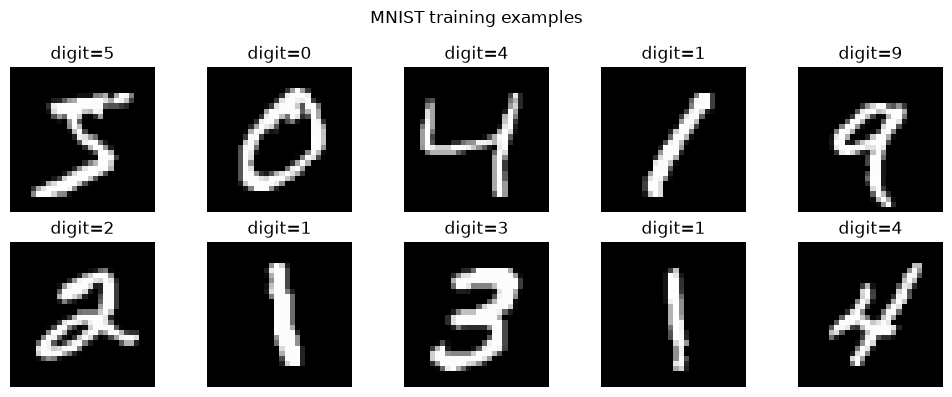

In [2]:
class_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .rename_axis("digit")
    .to_frame("count")
)
display(class_counts)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.flat, train_images_raw[:10], train_labels[:10]):
    axis.imshow(image, cmap="gray")
    axis.set_title(f"digit={label}")
    axis.axis("off")
fig.suptitle("MNIST training examples")
fig.tight_layout()
display(fig)
plt.close(fig)


## 2. Preprocess the data

Flatten each image to 784 features, normalize pixels to [0, 1], one-hot
encode the labels, and create a fixed 54,000 / 6,000 train/validation split.


In [3]:
def one_hot(labels, class_count=NUM_CLASSES):
    encoded = np.zeros((len(labels), class_count), dtype=np.float32)
    encoded[np.arange(len(labels)), labels.astype(np.int64)] = 1.0
    return encoded


all_images = train_images_raw.reshape((len(train_images_raw), IMAGE_SIZE)).astype(
    np.float32
) / 255.0
test_images = test_images_raw.reshape((len(test_images_raw), IMAGE_SIZE)).astype(
    np.float32
) / 255.0
all_targets = one_hot(train_labels)
test_targets = one_hot(test_labels)

validation_count = 6_000
train_images = all_images[:-validation_count]
train_targets = all_targets[:-validation_count]
validation_images = all_images[-validation_count:]
validation_targets = all_targets[-validation_count:]

assert train_images.shape == (54_000, IMAGE_SIZE)
assert validation_images.shape == (6_000, IMAGE_SIZE)
assert test_images.shape == (10_000, IMAGE_SIZE)
assert train_targets.shape == (54_000, NUM_CLASSES)
assert validation_targets.shape == (6_000, NUM_CLASSES)
assert test_targets.shape == (10_000, NUM_CLASSES)
assert np.isclose(train_images.min(), 0.0)
assert train_images.max() <= 1.0
assert np.isclose(train_targets.sum(axis=1), 1.0).all()
print("Preprocessed: flattened 784 features, scaled pixels to [0, 1], one-hot labels.")
print("Split: 54,000 train / 6,000 validation / 10,000 test.")


Preprocessed: flattened 784 features, scaled pixels to [0, 1], one-hot labels.
Split: 54,000 train / 6,000 validation / 10,000 test.


## 3. Build the JAX model

The output layer returns ten logits, one for each digit. The next cell defines
the forward pass, loss, autodiff step, optimizer state, and evaluation loop
directly with JAX.


In [4]:
import jax
import jax.numpy as jnp

print(f"JAX {jax.__version__}; devices: {jax.devices()}")


def make_jax_parameters(hidden_units=(512,)):
    dimensions = (IMAGE_SIZE, *hidden_units, NUM_CLASSES)
    key = jax.random.PRNGKey(RANDOM_STATE)
    parameters = []
    for layer_index, (input_size, output_size) in enumerate(
        zip(dimensions[:-1], dimensions[1:])
    ):
        key, weight_key = jax.random.split(key)
        weights = jax.random.normal(
            weight_key, (input_size, output_size), dtype=jnp.float32
        ) * jnp.sqrt(2.0 / input_size)
        biases = jnp.zeros((output_size,), dtype=jnp.float32)
        parameters.append({"weights": weights, "biases": biases})
    return tuple(parameters)


def jax_logits(parameters, features):
    values = features
    for layer in parameters[:-1]:
        values = jax.nn.relu(values @ layer["weights"] + layer["biases"])
    final_layer = parameters[-1]
    return values @ final_layer["weights"] + final_layer["biases"]


def jax_loss_accuracy(parameters, features, targets):
    logits = jax_logits(parameters, features)
    log_probabilities = jax.nn.log_softmax(logits, axis=1)
    loss = -jnp.mean(jnp.sum(targets * log_probabilities, axis=1))
    accuracy = jnp.mean(
        jnp.argmax(logits, axis=1) == jnp.argmax(targets, axis=1)
    )
    return loss, accuracy


@jax.jit
def jax_logits_compiled(parameters, features):
    return jax_logits(parameters, features)


@jax.jit
def jax_sgd_step(parameters, features, targets, learning_rate):
    (loss, accuracy), gradients = jax.value_and_grad(
        jax_loss_accuracy, has_aux=True
    )(parameters, features, targets)
    parameters = jax.tree_util.tree_map(
        lambda parameter, gradient: parameter - learning_rate * gradient,
        parameters,
        gradients,
    )
    return parameters, loss, accuracy


@jax.jit
def jax_adam_step(
    parameters,
    first_moment,
    second_moment,
    step,
    features,
    targets,
    learning_rate,
):
    (loss, accuracy), gradients = jax.value_and_grad(
        jax_loss_accuracy, has_aux=True
    )(parameters, features, targets)
    beta_1 = 0.9
    beta_2 = 0.999
    epsilon = 1e-8
    step = step + 1
    first_moment = jax.tree_util.tree_map(
        lambda moment, gradient: beta_1 * moment + (1.0 - beta_1) * gradient,
        first_moment,
        gradients,
    )
    second_moment = jax.tree_util.tree_map(
        lambda moment, gradient: beta_2 * moment + (1.0 - beta_2) * jnp.square(gradient),
        second_moment,
        gradients,
    )
    correction_1 = 1.0 - beta_1**step
    correction_2 = 1.0 - beta_2**step
    parameters = jax.tree_util.tree_map(
        lambda parameter, first, second: parameter
        - learning_rate * (first / correction_1)
        / (jnp.sqrt(second / correction_2) + epsilon),
        parameters,
        first_moment,
        second_moment,
    )
    return parameters, first_moment, second_moment, step, loss, accuracy


def evaluate_model(parameters, features, targets, return_predictions=False):
    total_loss = 0.0
    total_correct = 0
    predictions = []
    for start in range(0, len(features), BATCH_SIZE):
        batch_features = jnp.asarray(features[start : start + BATCH_SIZE])
        batch_targets = jnp.asarray(targets[start : start + BATCH_SIZE])
        logits = jax_logits_compiled(parameters, batch_features)
        log_probabilities = jax.nn.log_softmax(logits, axis=1)
        batch_loss = -jnp.mean(jnp.sum(batch_targets * log_probabilities, axis=1))
        batch_predictions = jnp.argmax(logits, axis=1)
        batch_labels = jnp.argmax(batch_targets, axis=1)
        total_loss += float(batch_loss) * len(batch_features)
        total_correct += int(jnp.sum(batch_predictions == batch_labels))
        if return_predictions:
            predictions.append(np.asarray(batch_predictions))
    result = total_loss / len(features), total_correct / len(features)
    if return_predictions:
        return result[0], result[1], np.concatenate(predictions)
    return result


def train_model(
    hidden_units=(512,), optimizer_name="sgd", learning_rate=0.01, epochs=10
):
    parameters = make_jax_parameters(hidden_units)
    first_moment = second_moment = None
    if optimizer_name == "adam":
        first_moment = jax.tree_util.tree_map(jnp.zeros_like, parameters)
        second_moment = jax.tree_util.tree_map(jnp.zeros_like, parameters)
    step = jnp.array(0, dtype=jnp.int32)
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    rng = np.random.default_rng(RANDOM_STATE)
    for epoch in range(epochs):
        permutation = rng.permutation(len(train_images))
        batch_losses = []
        batch_accuracies = []
        for start in range(0, len(train_images), BATCH_SIZE):
            indices = permutation[start : start + BATCH_SIZE]
            batch_features = jnp.asarray(train_images[indices])
            batch_targets = jnp.asarray(train_targets[indices])
            if optimizer_name == "adam":
                (
                    parameters,
                    first_moment,
                    second_moment,
                    step,
                    batch_loss,
                    batch_accuracy,
                ) = jax_adam_step(
                    parameters,
                    first_moment,
                    second_moment,
                    step,
                    batch_features,
                    batch_targets,
                    learning_rate,
                )
            else:
                parameters, batch_loss, batch_accuracy = jax_sgd_step(
                    parameters, batch_features, batch_targets, learning_rate
                )
            batch_losses.append(float(batch_loss))
            batch_accuracies.append(float(batch_accuracy))
        val_loss, val_accuracy = evaluate_model(
            parameters, validation_images, validation_targets
        )
        history["loss"].append(float(np.mean(batch_losses)))
        history["accuracy"].append(float(np.mean(batch_accuracies)))
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        print(
            f"epoch {epoch + 1:02d}/{epochs} - "
            f"loss: {history['loss'][-1]:.4f} - "
            f"accuracy: {history['accuracy'][-1]:.4f} - "
            f"val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}"
        )
    return parameters, pd.DataFrame(history)


print("Model: 784 -> 512 -> 10; ReLU hidden activation; linear logits.")
print("Loss: manual one-hot log-softmax cross-entropy; optimizer: SGD or Adam.")


JAX 0.11.1; devices: [CpuDevice(id=0)]
Model: 784 -> 512 -> 10; ReLU hidden activation; linear logits.
Loss: manual one-hot log-softmax cross-entropy; optimizer: SGD or Adam.


## 4. Model training

Train the baseline for ten epochs with batch size 128. Every epoch records
training and validation loss/accuracy so the learning curves can answer the
overfitting question.


In [5]:
baseline, history_frame = train_model(
    hidden_units=(512,),
    optimizer_name="sgd",
    learning_rate=0.01,
    epochs=10,
)
display(history_frame.round(4))


epoch 01/10 - loss: 1.1179 - accuracy: 0.7399 - val_loss: 0.5681 - val_accuracy: 0.8862


epoch 02/10 - loss: 0.5387 - accuracy: 0.8700 - val_loss: 0.3932 - val_accuracy: 0.9085


epoch 03/10 - loss: 0.4329 - accuracy: 0.8867 - val_loss: 0.3324 - val_accuracy: 0.9162


epoch 04/10 - loss: 0.3848 - accuracy: 0.8970 - val_loss: 0.3008 - val_accuracy: 0.9200


epoch 05/10 - loss: 0.3553 - accuracy: 0.9028 - val_loss: 0.2804 - val_accuracy: 0.9260


...

epoch 07/10 - loss: 0.3186 - accuracy: 0.9113 - val_loss: 0.2541 - val_accuracy: 0.9298


epoch 08/10 - loss: 0.3054 - accuracy: 0.9147 - val_loss: 0.2441 - val_accuracy: 0.9330


epoch 09/10 - loss: 0.2943 - accuracy: 0.9183 - val_loss: 0.2356 - val_accuracy: 0.9353


epoch 10/10 - loss: 0.2846 - accuracy: 0.9213 - val_loss: 0.2286 - val_accuracy: 0.9368


,loss,accuracy,val_loss,val_accuracy
0,1.1179,0.7399,0.5681,0.8862
1,0.5387,0.8700,0.3932,0.9085
2,0.4329,0.8867,0.3324,0.9162
3,0.3848,0.8970,0.3008,0.9200
4,0.3553,0.9028,0.2804,0.9260
5,0.3346,0.9072,0.2662,0.9272
6,0.3186,0.9113,0.2541,0.9298
7,0.3054,0.9147,0.2441,0.9330
8,0.2943,0.9183,0.2356,0.9353
9,0.2846,0.9213,0.2286,0.9368


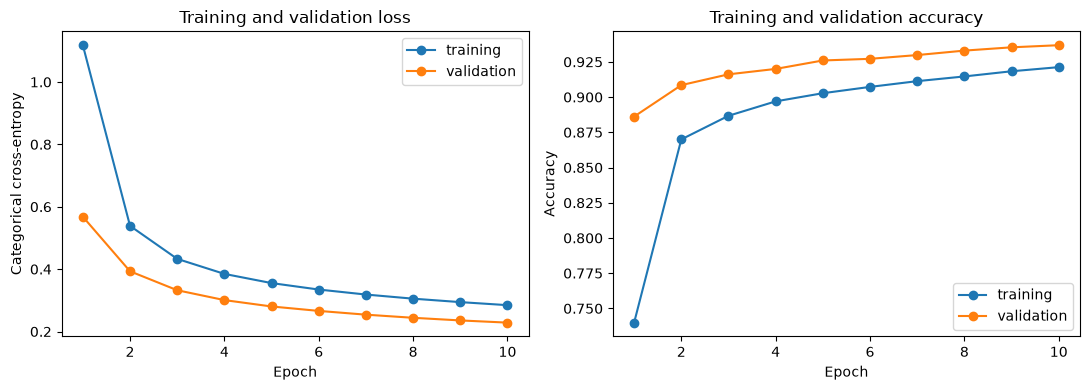

Lowest validation loss: epoch 10
Highest validation accuracy: epoch 10
Final validation-minus-training loss gap: -0.0560
Interpretation: no loss-based overfitting is visible by the final epoch.


In [6]:
epochs = np.arange(1, len(history_frame) + 1)
best_val_loss_epoch = int(history_frame["val_loss"].idxmin() + 1)
best_val_accuracy_epoch = int(history_frame["val_accuracy"].idxmax() + 1)
final_loss_gap = float(history_frame["val_loss"].iloc[-1] - history_frame["loss"].iloc[-1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history_frame["loss"], "o-", label="training")
axes[0].plot(epochs, history_frame["val_loss"], "o-", label="validation")
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical cross-entropy")
axes[0].legend()
axes[1].plot(epochs, history_frame["accuracy"], "o-", label="training")
axes[1].plot(epochs, history_frame["val_accuracy"], "o-", label="validation")
axes[1].set_title("Training and validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dnn_baseline_history.png", dpi=150)
display(fig)
plt.close(fig)

print(f"Lowest validation loss: epoch {best_val_loss_epoch}")
print(f"Highest validation accuracy: epoch {best_val_accuracy_epoch}")
print(f"Final validation-minus-training loss gap: {final_loss_gap:.4f}")
if best_val_loss_epoch < len(history_frame):
    print(
        "Interpretation: validation loss rises after its minimum, "
        "so overfitting starts after the best validation-loss epoch."
    )
else:
    print("Interpretation: no loss-based overfitting is visible by the final epoch.")


**Answer — overfitting.** Use the printed validation-loss minimum:
if validation loss stops improving while training loss keeps decreasing,
overfitting begins after that epoch. A small stable train/validation gap
suggests lower variance; a large gap suggests higher variance. Both losses
remaining high suggests underfitting/high bias.


## 5. Model evaluation

Evaluate on the untouched test set. Convert logits to predicted labels, build a
confusion matrix with NumPy, and calculate per-class precision, recall, and F1
without a metric helper.


In [7]:
def confusion_matrix_np(true_labels, predicted_labels, class_count=NUM_CLASSES):
    matrix = np.zeros((class_count, class_count), dtype=np.int64)
    np.add.at(matrix, (true_labels, predicted_labels), 1)
    return matrix


def classification_metrics(matrix):
    true_positive = np.diag(matrix).astype(np.float64)
    support = matrix.sum(axis=1).astype(np.float64)
    predicted = matrix.sum(axis=0).astype(np.float64)
    precision = np.divide(
        true_positive,
        predicted,
        out=np.zeros_like(true_positive),
        where=predicted != 0,
    )
    recall = np.divide(
        true_positive,
        support,
        out=np.zeros_like(true_positive),
        where=support != 0,
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(true_positive),
        where=(precision + recall) != 0,
    )
    metrics = pd.DataFrame(
        {
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "support": support.astype(np.int64),
        },
        index=[str(label) for label in range(NUM_CLASSES)],
    )
    metrics.index.name = "label"
    metrics.loc["macro avg"] = [
        precision.mean(),
        recall.mean(),
        f1.mean(),
        support.sum(),
    ]
    weights = support / support.sum()
    metrics.loc["weighted avg"] = [
        np.sum(precision * weights),
        np.sum(recall * weights),
        np.sum(f1 * weights),
        support.sum(),
    ]
    metrics.loc["accuracy"] = [
        np.nan,
        np.nan,
        true_positive.sum() / support.sum(),
        support.sum(),
    ]
    return metrics


Test loss: 0.2654
Test accuracy: 0.9279


,split,loss,accuracy
0,train (final epoch),0.2846,0.9213
1,validation (final epoch),0.2286,0.9368
2,test,0.2654,0.9279


Most frequent confusion: true 9 predicted as 4 (36 cases).
Macro precision: 0.9273; macro recall: 0.9271.


,precision,recall,f1-score,support
label,,,,
0,0.9497,0.9816,0.9654,980.0
1,0.9711,0.9762,0.9736,1135.0
2,0.9260,0.8973,0.9114,1032.0
3,0.9092,0.9218,0.9154,1010.0
4,0.9139,0.9399,0.9267,982.0
5,0.9305,0.8857,0.9075,892.0
6,0.9380,0.9478,0.9429,958.0
7,0.9384,0.9183,0.9282,1028.0
8,0.8859,0.9004,0.8931,974.0


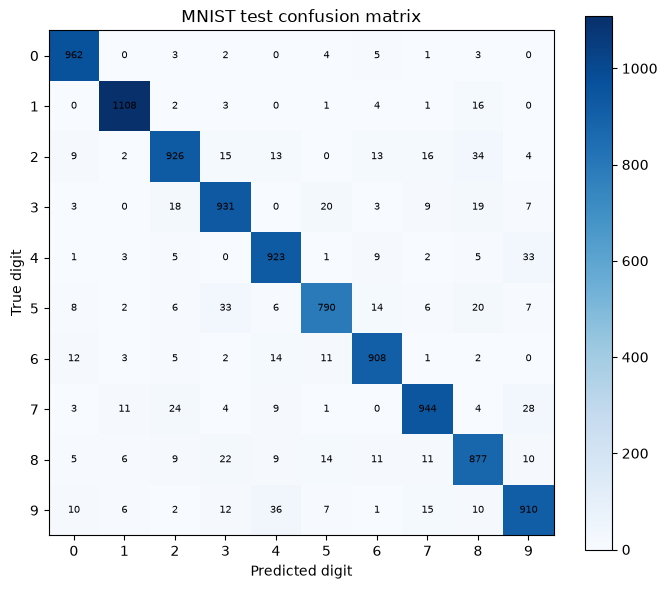

In [8]:
test_loss, test_accuracy, predicted_labels = evaluate_model(
    baseline, test_images, test_targets, return_predictions=True
)
assert predicted_labels.shape == test_labels.shape
assert np.isfinite(predicted_labels).all()

train_loss = float(history_frame["loss"].iloc[-1])
train_accuracy = float(history_frame["accuracy"].iloc[-1])
val_loss = float(history_frame["val_loss"].iloc[-1])
val_accuracy = float(history_frame["val_accuracy"].iloc[-1])
evaluation_summary = pd.DataFrame(
    [
        {"split": "train (final epoch)", "loss": train_loss, "accuracy": train_accuracy},
        {"split": "validation (final epoch)", "loss": val_loss, "accuracy": val_accuracy},
        {"split": "test", "loss": test_loss, "accuracy": test_accuracy},
    ]
)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
display(evaluation_summary.round(4))

labels = np.arange(NUM_CLASSES)
cm = confusion_matrix_np(test_labels, predicted_labels)
metrics_frame = classification_metrics(cm)
metrics_frame.to_csv(OUTPUT_DIR / "metrics.csv")
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
true_digit, predicted_digit = np.unravel_index(
    np.argmax(off_diagonal), off_diagonal.shape
)
most_common_error_count = int(off_diagonal[true_digit, predicted_digit])
print(
    f"Most frequent confusion: true {true_digit} predicted as "
    f"{predicted_digit} ({most_common_error_count} cases)."
)
print(
    f"Macro precision: {metrics_frame.loc['macro avg', 'precision']:.4f}; "
    f"macro recall: {metrics_frame.loc['macro avg', 'recall']:.4f}."
)
display(metrics_frame.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(cm, cmap="Blues")
fig.colorbar(image, ax=ax)
ax.set_title("MNIST test confusion matrix")
ax.set_xlabel("Predicted digit")
ax.set_ylabel("True digit")
ax.set_xticks(labels)
ax.set_yticks(labels)
for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        ax.text(column, row, cm[row, column], ha="center", va="center", fontsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dnn_confusion_matrix.png", dpi=150)
display(fig)
plt.close(fig)


**Answer — confusion matrix.** The printed true-to-predicted pair
is the class pair the model confuses most often. Precision asks how many
predictions of a digit are correct; recall asks how many true examples of that
digit are found. Macro averages weight all ten digits equally.


## 6. Model tuning

Compare two SGD learning rates, Adam, and one deeper network. Each candidate
uses the same split, batch size, initialization seed, and three-epoch budget
for a short, fair experiment.


In [9]:
tuning_configs = [
    {
        "name": "SGD lr=0.001",
        "optimizer": "sgd",
        "learning_rate": 0.001,
        "hidden_units": (512,),
    },
    {
        "name": "SGD lr=0.05",
        "optimizer": "sgd",
        "learning_rate": 0.05,
        "hidden_units": (512,),
    },
    {
        "name": "Adam",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "hidden_units": (512,),
    },
    {
        "name": "Adam deeper",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "hidden_units": (256, 128),
    },
]

tuning_rows = []
for config in tuning_configs:
    candidate, tuned_history = train_model(
        hidden_units=config["hidden_units"],
        optimizer_name=config["optimizer"],
        learning_rate=config["learning_rate"],
        epochs=3,
    )
    tuned_test_loss, tuned_test_accuracy = evaluate_model(
        candidate, test_images, test_targets
    )
    tuning_rows.append(
        {
            "model": config["name"],
            "optimizer": config["optimizer"],
            "learning_rate": config["learning_rate"],
            "hidden_units": str(config["hidden_units"]),
            "best_val_accuracy": tuned_history["val_accuracy"].max(),
            "test_loss": tuned_test_loss,
            "test_accuracy": tuned_test_accuracy,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
tuning_results.to_csv(OUTPUT_DIR / "tuning_results.csv", index=False)
display(tuning_results.round(4))
best_tuned = tuning_results.iloc[0]
print(
    f"Best short-run test accuracy: {best_tuned['model']} "
    f"({best_tuned['test_accuracy']:.4f})."
)


epoch 01/3 - loss: 2.1075 - accuracy: 0.3259 - val_loss: 1.8472 - val_accuracy: 0.5615


epoch 02/3 - loss: 1.6743 - accuracy: 0.6326 - val_loss: 1.4726 - val_accuracy: 0.7282


epoch 03/3 - loss: 1.3718 - accuracy: 0.7300 - val_loss: 1.2059 - val_accuracy: 0.7928


epoch 01/3 - loss: 0.5741 - accuracy: 0.8544 - val_loss: 0.2827 - val_accuracy: 0.9247


epoch 02/3 - loss: 0.3123 - accuracy: 0.9129 - val_loss: 0.2291 - val_accuracy: 0.9373


...

epoch 01/3 - loss: 0.2782 - accuracy: 0.9192 - val_loss: 0.1225 - val_accuracy: 0.9650


epoch 02/3 - loss: 0.1063 - accuracy: 0.9677 - val_loss: 0.0829 - val_accuracy: 0.9767


epoch 03/3 - loss: 0.0689 - accuracy: 0.9787 - val_loss: 0.0825 - val_accuracy: 0.9770


,model,optimizer,learning_rate,hidden_units,best_val_accuracy,test_loss,test_accuracy
0,Adam,adam,0.001,"(512,)",0.9768,0.0874,0.9735
1,Adam deeper,adam,0.001,"(256, 128)",0.9770,0.0866,0.9722
2,SGD lr=0.05,sgd,0.050,"(512,)",0.9465,0.2359,0.9355
3,SGD lr=0.001,sgd,0.001,"(512,)",0.7928,1.2268,0.7651


Best short-run test accuracy: Adam (0.9735).


## 7. Discussion and result

The tuning table is the evidence for the discussion. A larger learning rate
may converge faster but can become unstable; adaptive optimization can reach a
strong result in fewer epochs; and extra hidden layers increase capacity but
can also increase variance. The best setting depends on the metric and
training budget, not just model size.
